https://www.kaggle.com/datasets/shambhurajejagadale/student-performance-prediction-dataset

---
## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 2. Load Dataset

In [ ]:
import io

# Cara 1: Upload manual via Colab
df = pd.read_excel('/content/student_dataset.xlsx')
print(f'✅ Dataset berhasil dimuat!')
print(f'   Jumlah baris   : {df.shape[0]:,}')
print(f'   Jumlah kolom   : {df.shape[1]}')

✅ Dataset berhasil dimuat!
   Jumlah baris   : 1,999
   Jumlah kolom   : 8


In [ ]:
df.head(10)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


---
## 3. Gambaran Umum Dataset

In [ ]:
# Tampilkan 5 baris pertama
print('=== 5 Baris Pertama ===')
df.head()

=== 5 Baris Pertama ===


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [ ]:
# Struktur data
print('=== Info Dataset ===')
df.info()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            1999 non-null   int64  
 1   attendance             1999 non-null   int64  
 2   sleep_hours            1999 non-null   int64  
 3   internet_usage         1999 non-null   int64  
 4   assignments_completed  1999 non-null   int64  
 5   previous_score         1999 non-null   int64  
 6   exam_score             1999 non-null   float64
 7   placement_status       1999 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 125.1+ KB


In [ ]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe(include='all').T

=== Statistik Deskriptif ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
study_hours,1999.0,NaN,NaN,NaN,5.901951,3.180803,1.0,3.0,6.0,9.0,11.0
attendance,1999.0,NaN,NaN,NaN,70.132566,18.018313,40.0,55.0,70.0,86.0,100.0
sleep_hours,1999.0,NaN,NaN,NaN,6.490245,1.714269,4.0,5.0,6.0,8.0,9.0
internet_usage,1999.0,NaN,NaN,NaN,6.066033,3.138071,1.0,3.0,6.0,9.0,11.0
assignments_completed,1999.0,NaN,NaN,NaN,10.115558,6.039754,0.0,5.0,10.0,15.0,20.0
previous_score,1999.0,NaN,NaN,NaN,65.281141,17.477284,35.0,50.0,66.0,81.0,95.0
exam_score,1999.0,NaN,NaN,NaN,86.835643,14.918533,26.89,77.355,91.92,100.0,100.0
placement_status,1999,2,Placed,1681,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4. Analisis Missing Values

In [ ]:
missinmissingg = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Jumlah Missing', ascending=False)

print('=== Missing Values per Kolom ===')
print(missing_df[missing_df['Jumlah Missing'] > 0])

# Visualisasi
missing_nonzero = missing_df[missing_df['Jumlah Missing'] > 0]

if not missing_nonzero.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(missing_nonzero.index, missing_nonzero['Persentase (%)'], color=['#e74c3c', '#e67e22'])
    ax.bar_label(bars, labels=[f'{v:.2f}%' for v in missing_nonzero['Persentase (%)']], padding=3)
    ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_ylim(0, max(missing_nonzero['Persentase (%)']) * 1.3)
    plt.tight_layout()
    plt.show()
    print('📝 Insight: Missing values < 2%, akan ditangani dengan imputasi.')
else:
    print('✅ Tidak ada missing values.')

=== Missing Values per Kolom ===
Empty DataFrame
Columns: [Jumlah Missing, Persentase (%)]
Index: []
✅ Tidak ada missing values.


## 5. Analisis Duplikat

In [ ]:
n_dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dup}')

if n_dup > 0:
    print('⚠️  Terdapat duplikat, perlu ditangani!')
    print(df[df.duplicated()].head())
else:
    print('✅ Tidak ada duplikat.')

Jumlah baris duplikat: 0
✅ Tidak ada duplikat.


---
## 6. Distribusi Variabel Target (Exam Score)

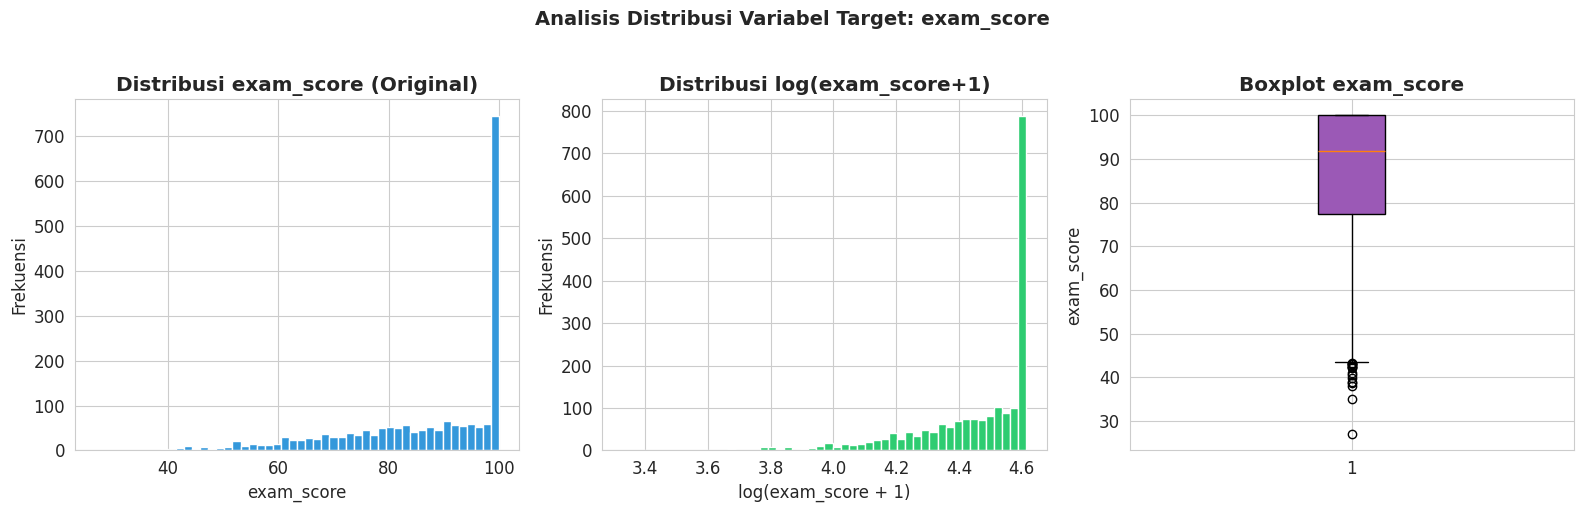


=== Statistik exam_score ===
count    1999.0000
mean       86.8356
std        14.9185
min        26.8900
25%        77.3550
50%        91.9200
75%       100.0000
max       100.0000
Name: exam_score, dtype: float64

Skewness : -1.0409
Kurtosis : 0.2428

📝 Insight: Distribusi exam_score dianalisis.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(df['exam_score'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Distribusi exam_score (Original)', fontweight='bold')
axes[0].set_xlabel('exam_score')
axes[0].set_ylabel('Frekuensi')

# Log-transformed histogram (optional, consider if data is highly skewed)
# For exam_score, log transform might not be necessary if it's already somewhat normal or bounded.
# Let's keep it for now as a demonstration, but a review might be needed based on its actual distribution.
log_exam_score = np.log1p(df['exam_score'])
axes[1].hist(log_exam_score, bins=50, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribusi log(exam_score+1)', fontweight='bold')
axes[1].set_xlabel('log(exam_score + 1)')
axes[1].set_ylabel('Frekuensi')

# Boxplot
axes[2].boxplot(df['exam_score'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#9b59b6', color='black'))
axes[2].set_title('Boxplot exam_score', fontweight='bold')
axes[2].set_ylabel('exam_score')

plt.suptitle('Analisis Distribusi Variabel Target: exam_score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n=== Statistik exam_score ===')
print(df['exam_score'].describe().round(4))
print(f'\nSkewness : {df["exam_score"].skew():.4f}')
print(f'Kurtosis : {df["exam_score"].kurtosis():.4f}')
print('\n📝 Insight: Distribusi exam_score dianalisis.')

Berdasarkan visualisasi dan statistik deskriptif dari exam_score:

- Distribusi: Histogram menunjukkan bahwa sebagian besar nilai exam_score terkonsentrasi di bagian atas skala, mendekati nilai maksimum (100). Ada sejumlah besar siswa yang mencapai nilai tinggi.
- Skewness (Kecondongan): Nilai skewness adalah -1.0409, yang menunjukkan bahwa distribusi ini cenderung miring ke kiri (negatively skewed). Ini berarti bahwa 'ekor' distribusi lebih panjang di sisi kiri, dan mayoritas data memiliki nilai yang lebih tinggi dari rata-rata.
- Kurtosis: Nilai kurtosis adalah 0.2428, yang relatif dekat dengan 0 (nilai kurtosis untuk distribusi normal). Ini menunjukkan bahwa distribusi memiliki 'ekor' yang tidak terlalu berat atau ringan dibandingkan dengan distribusi normal, dan puncaknya tidak terlalu tajam.
- Statistik Deskriptif:
Mean (Rata-rata): Sekitar 86.84
Median: Sekitar 91.92
Max (Maksimum): 100.00
Perbedaan antara mean dan median (median > mean) juga mengkonfirmasi adanya skewness negatif.
- Boxplot: Boxplot mengkonfirmasi bahwa ada beberapa outlier di bagian bawah distribusi (nilai ujian yang jauh lebih rendah), yang menandakan adanya siswa dengan nilai yang sangat rendah dibandingkan mayoritas. Namun, kotak IQR (interquartile range) menunjukkan bahwa sebagian besar siswa memiliki nilai yang tinggi, dengan kuartil ke-3 (75%) berada di 100.

Kesimpulan: Secara keseluruhan, exam_score memiliki distribusi yang sangat miring ke kiri, dengan banyak siswa mencapai nilai yang sangat tinggi. Meskipun demikian, ada beberapa siswa dengan nilai yang jauh lebih rendah, yang terlihat sebagai outlier.

---
## 7. Distribusi Fitur Numerik

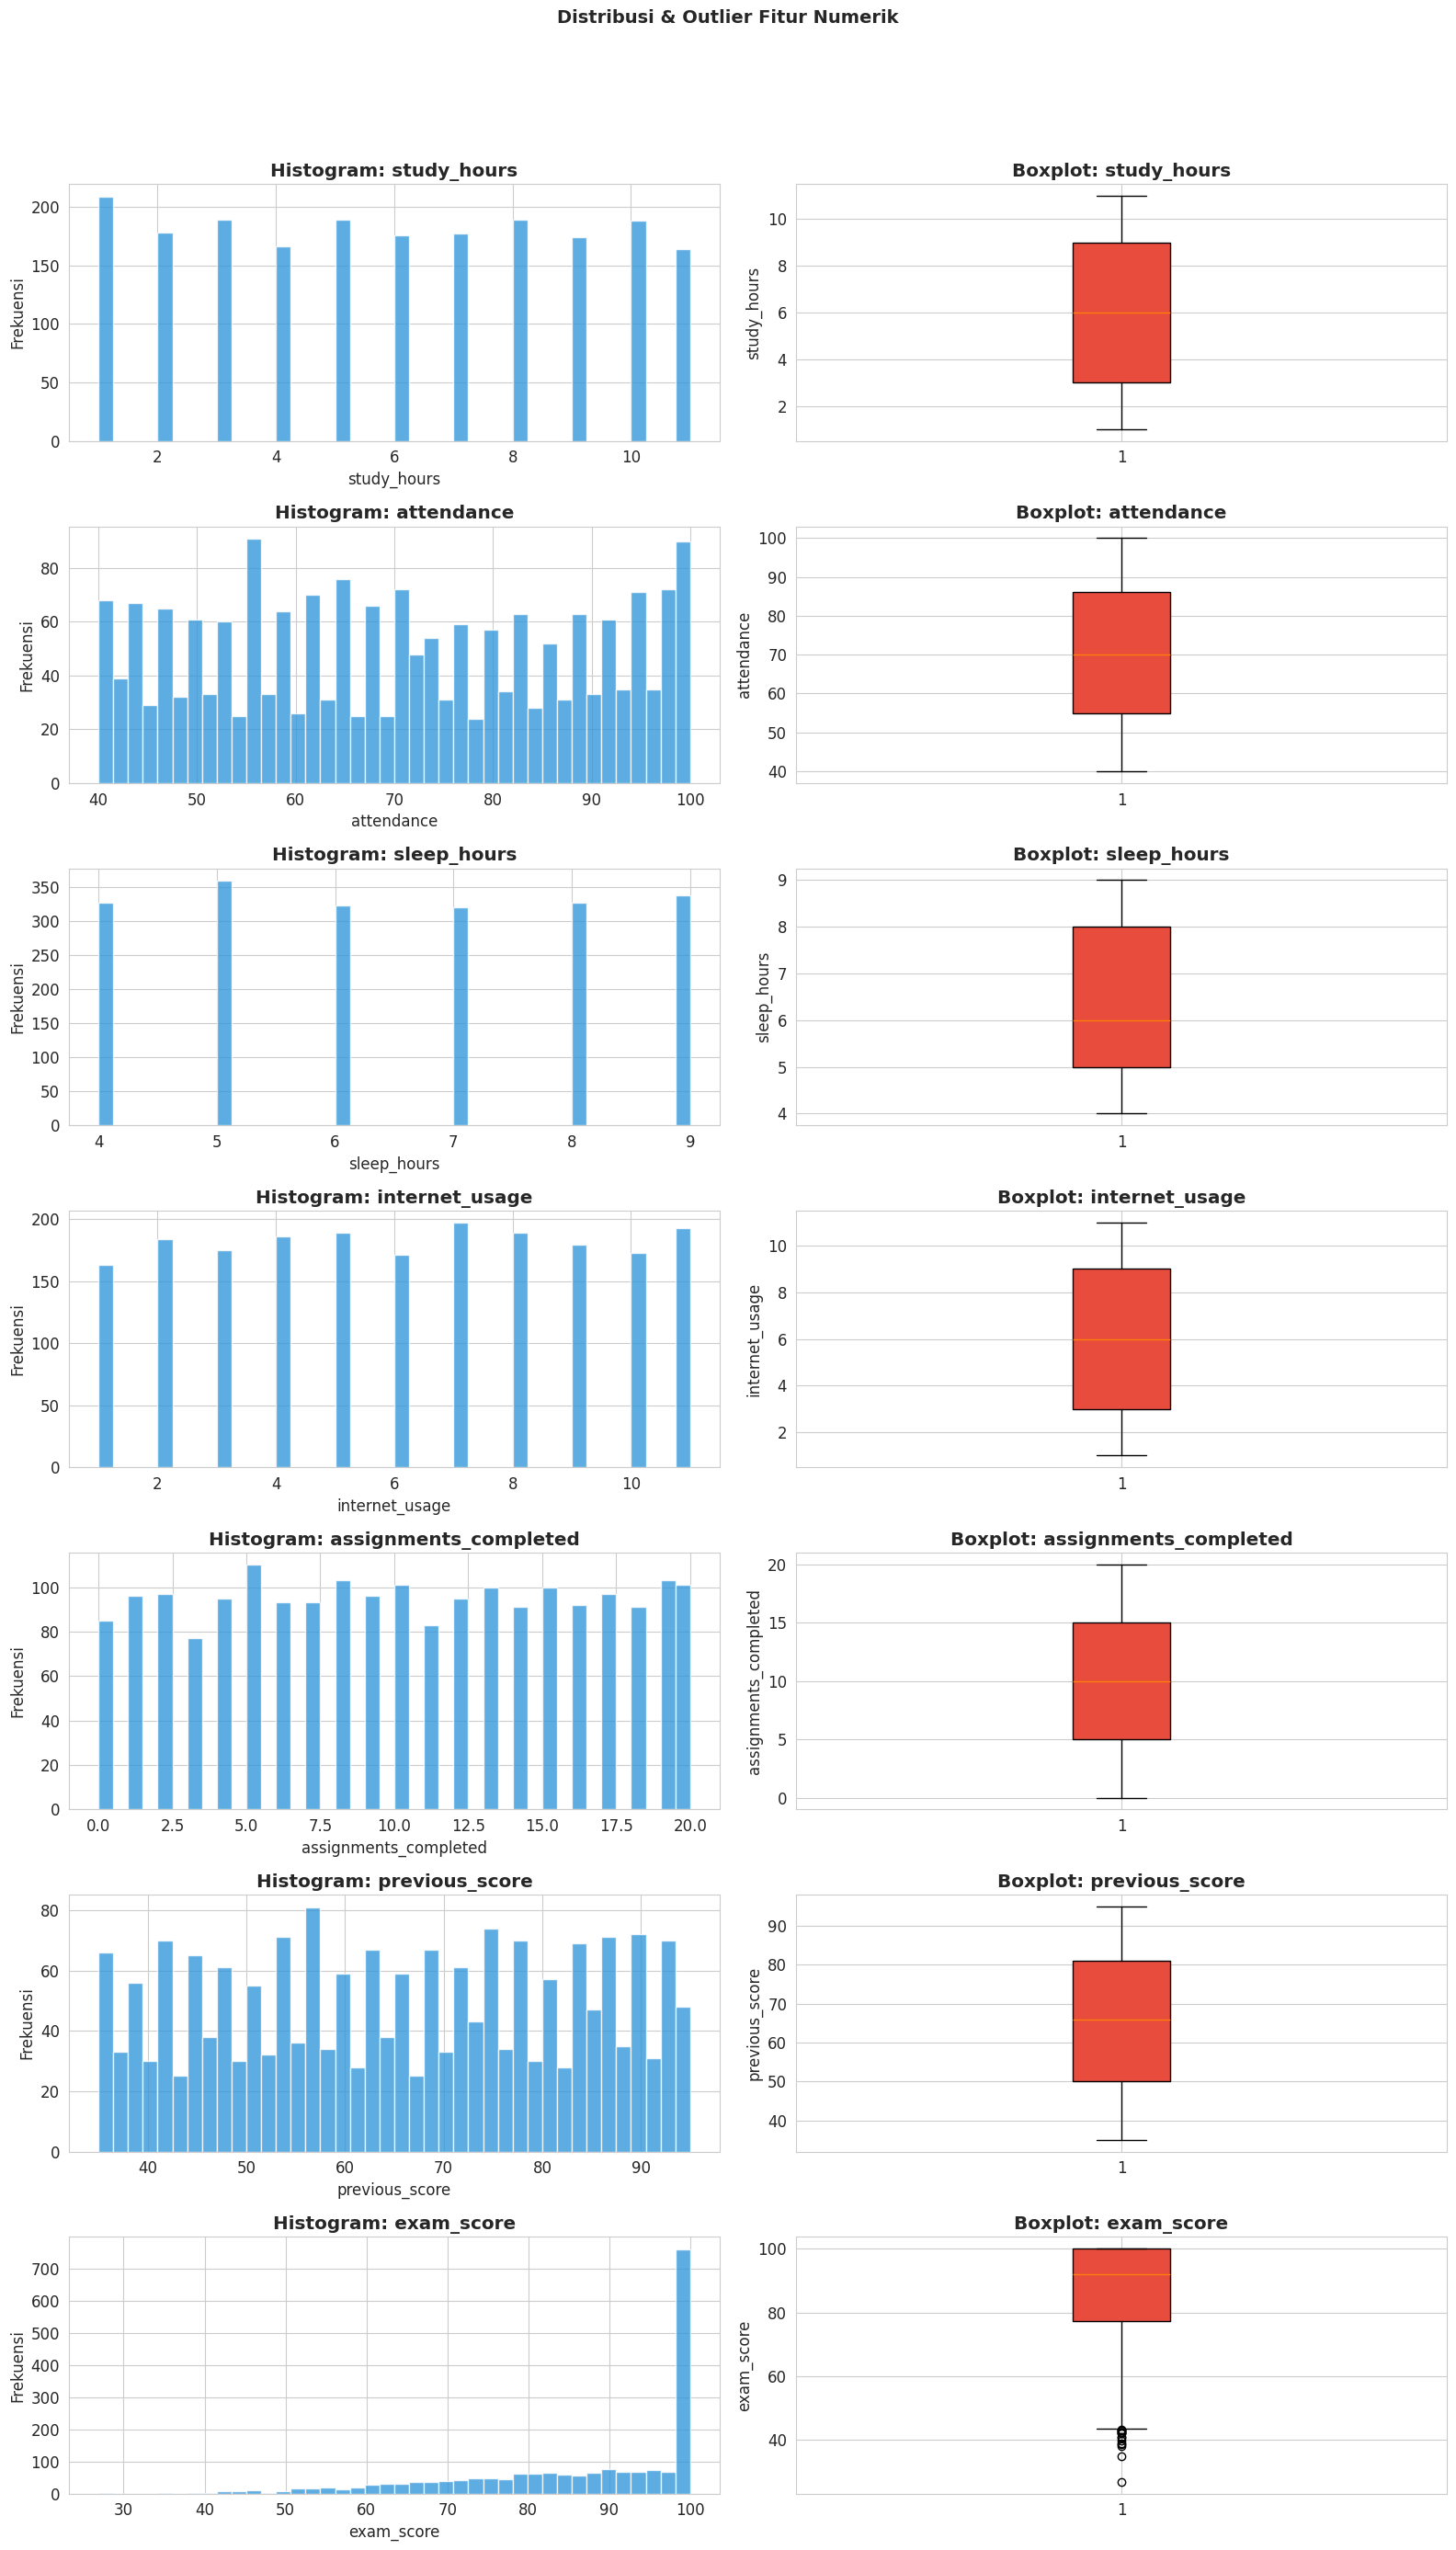

In [ ]:
num_cols = ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(16, 4 * len(num_cols))) # Adjusted figsize and rows

for i, col_name in enumerate(num_cols):
    # Histogram
    axes[i, 0].hist(df[col_name].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'Histogram: {col_name}', fontweight='bold')
    axes[i, 0].set_xlabel(col_name)
    axes[i, 0].set_ylabel('Frekuensi')

    # Boxplot
    axes[i, 1].boxplot(df[col_name].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#e74c3c', color='black'))
    axes[i, 1].set_title(f'Boxplot: {col_name}', fontweight='bold')
    axes[i, 1].set_ylabel(col_name)

plt.suptitle('Distribusi & Outlier Fitur Numerik', fontsize=14, fontweight='bold', y=1.02) # Adjusted suptitle y position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjusted tight_layout to make space for suptitle
plt.show()

Interpretasi per Fitur:

study_hours (Durasi Belajar):

- Distribusi: Histogram menunjukkan distribusi yang cukup merata (uniform-like) di antara 1 hingga 11 jam, meskipun ada sedikit peningkatan frekuensi pada nilai-nilai genap. Tidak ada skewness yang jelas.
- Boxplot: Tidak menunjukkan adanya outlier. Median berada di sekitar 6 jam, dan datanya tersebar cukup simetris.

attendance (Kehadiran):

- Distribusi: Histogram menunjukkan distribusi yang cenderung tersebar luas, dengan beberapa puncak, tetapi tidak ada pola yang sangat dominan. Ada beberapa frekuensi yang lebih tinggi di sekitar 50-60% dan 80-90%.
- Boxplot: Tidak menunjukkan adanya outlier. Median di sekitar 70%, dengan rentang yang cukup lebar.

sleep_hours (Durasi Tidur):

- Distribusi: Histogram menunjukkan distribusi multimodus, dengan frekuensi tertinggi pada 4, 5, 6, 8, dan 9 jam tidur. Ini mengindikasikan kelompok-kelompok siswa yang memiliki pola tidur tertentu.
- Boxplot: Tidak menunjukkan adanya outlier. Median di sekitar 6 jam.

internet_usage (Penggunaan Internet):

- Distribusi: Mirip dengan study_hours, histogram menunjukkan distribusi yang relatif merata antara 1 hingga 11 jam. Tidak ada skewness yang jelas.
- Boxplot: Tidak menunjukkan adanya outlier. Median di sekitar 6 jam.

assignments_completed (Tugas yang Diselesaikan):

- Distribusi: Histogram menunjukkan distribusi yang cukup merata dari 0 hingga 20 tugas. Tidak ada skewness yang jelas.
- Boxplot: Tidak menunjukkan adanya outlier. Median di sekitar 10 tugas.

previous_score (Skor Sebelumnya):

- Distribusi: Histogram menunjukkan distribusi yang relatif merata, sedikit condong ke kiri, dari 35 hingga 95. Ada beberapa puncak kecil di sepanjang rentang ini.
- Boxplot: Tidak menunjukkan adanya outlier. Median di sekitar 66.

exam_score (Skor Ujian):

- Distribusi: Histogram menunjukkan distribusi yang sangat miring ke kiri (negatively skewed), dengan sebagian besar nilai terkonsentrasi di rentang nilai tinggi (sekitar 90-100). Ada sejumlah kecil nilai yang sangat rendah.
- Boxplot: Menunjukkan adanya beberapa outlier di sisi bawah (nilai ujian yang rendah), mengkonfirmasi adanya siswa dengan performa yang jauh di bawah rata-rata mayoritas. Median berada di sekitar 91.92, dan kuartil ketiga (75%) mencapai 100.


Kesimpulan Umum: Sebagian besar fitur numerik memiliki distribusi yang relatif merata atau terdistribusi secara simetris tanpa outlier. Namun, exam_score menonjol dengan distribusi yang sangat miring ke kiri dan keberadaan outlier di sisi bawah, menunjukkan bahwa meskipun banyak siswa berprestasi tinggi, ada juga beberapa yang kesulitan.

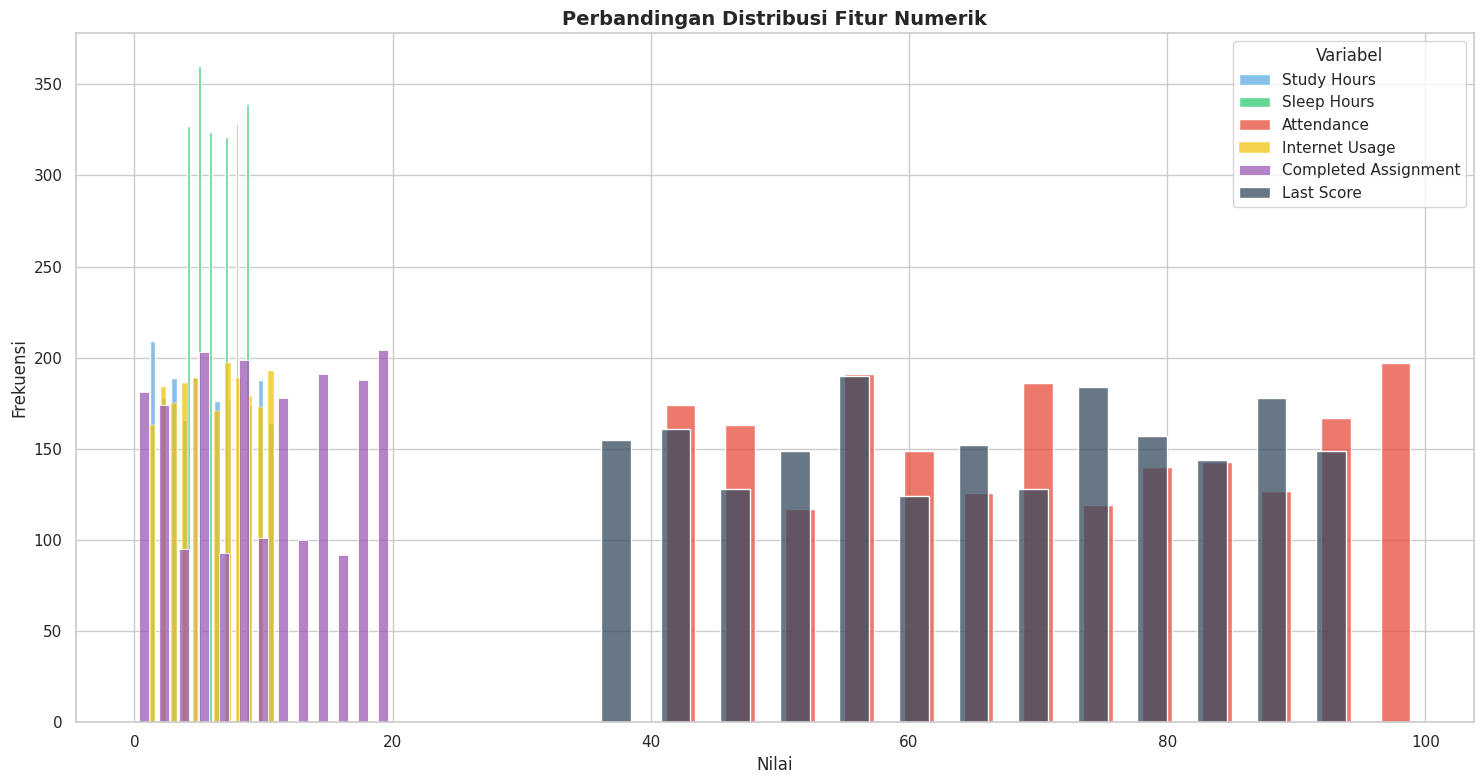

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SETTING STYLE & UKURAN ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8)) # Increased figure width and height

# --- 2. MEMBUAT HISTOGRAM GABUNGAN (BERDAMPINGAN) ---
# Kita panggil sns.histplot dua kali dalam satu plot yang sama
sns.histplot(
    data=df,
    x="study_hours",
    color="#5dade2",
    label="Study Hours",
    kde=False,
    shrink=0.5, # Adjusted shrink parameter
)
sns.histplot(
    data=df,
    x="sleep_hours",
    color="#2ecc71", # Changed color
    label="Sleep Hours",
    kde=False,
    shrink=0.5, # Adjusted shrink parameter
)
sns.histplot(
    data=df,
    x="attendance",
    color="#e74c3c", # Changed color
    label="Attendance",
    kde=False,
    shrink=0.5, # Adjusted shrink parameter
)
sns.histplot(
    data=df,
    x="internet_usage",
    color="#f1c40f", # Changed color
    label="Internet Usage",
    kde=False,
    shrink=0.5, # Adjusted shrink parameter
)
sns.histplot(
    data=df,
    x="assignments_completed",
    color="#9b59b6", # Changed color
    label="Completed Assignment",
    kde=False,
    shrink=0.5, # Adjusted shrink parameter
)
sns.histplot(
    data=df,
    x="previous_score",
    color="#34495e", # Changed color
    label="Last Score",
    kde=False,
    shrink=0.5, # Adjusted shrink parameter
)
# --- 3. KUSTOMISASI TAMPILAN ---
plt.title(
    "Perbandingan Distribusi Fitur Numerik", # Changed title to be more general
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Nilai", fontsize=12) # Changed x-axis label to be more general
plt.ylabel("Frekuensi", fontsize=12)

# Mengatur agar angka di sumbu X pas dengan jamnya (misal dari 1 sampai 11)
# plt.xticks(range(1, 12)) # This is too specific for multiple features, better to remove or adjust dynamically

# Menampilkan legenda/keterangan warna agar dosen tahu mana yang study dan sleep
plt.legend(title="Variabel", fontsize=11)

# Tampilkan grafik
plt.tight_layout()
plt.show()

Grafik ini menunjukkan distribusi frekuensi dari enam fitur numerik secara berdampingan. Mari kita interpretasikan:

- Rentang Nilai: Kita dapat melihat bahwa beberapa fitur seperti study_hours, sleep_hours, internet_usage, dan assignments_completed memiliki rentang nilai yang lebih kecil (misalnya, 0-20), sedangkan attendance dan previous_score memiliki rentang nilai yang lebih besar (misalnya, 30-100).

- Perbandingan Distribusi:

  - study_hours, internet_usage, assignments_completed: Tampaknya memiliki distribusi yang relatif uniform atau merata di seluruh rentang nilai mereka. Ini berarti setiap nilai dalam rentang tersebut memiliki frekuensi kemunculan yang relatif sama.
  - sleep_hours: Menunjukkan distribusi yang multi-modal (memiliki beberapa puncak), dengan frekuensi yang lebih tinggi pada angka-angka tertentu (misalnya, 4, 6, 8, 9 jam). Ini bisa mengindikasikan kelompok-kelompok siswa dengan kebiasaan tidur tertentu.
  - attendance: Distribusinya cukup tersebar, dengan beberapa puncak di berbagai rentang, menunjukkan variasi yang signifikan dalam tingkat kehadiran siswa.
  - previous_score: Distribusinya terlihat cenderung merata atau sedikit miring ke kiri, mirip dengan exam_score tetapi dengan nilai yang lebih rendah secara keseluruhan.

- Tumpang Tindih dan Skala: Karena fitur-fitur ini memiliki skala dan rentang yang sangat berbeda, beberapa histogram (terutama yang dengan rentang kecil seperti study_hours dan sleep_hours) tampak 'bertumpuk' di bagian kiri plot, sementara yang lain (attendance, previous_score) menyebar lebih jauh ke kanan.

---
## 8. Heatmap Korelasi Fitur Numerik

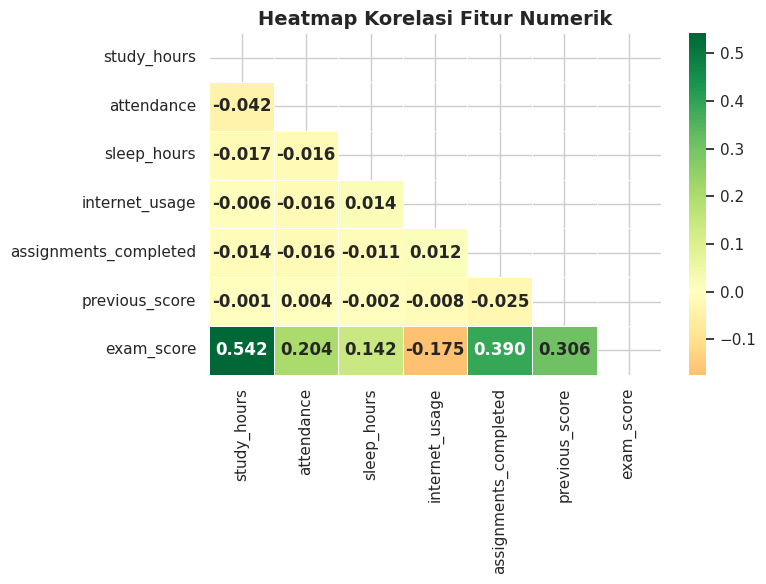

=== Korelasi dengan exam_score ===
exam_score               1.000000
study_hours              0.542184
assignments_completed    0.389990
previous_score           0.306151
attendance               0.204115
sleep_hours              0.141565
internet_usage          -0.174519
Name: exam_score, dtype: float64

📝 Insight: Fitur `assignments_completed` dan `previous_score` memiliki korelasi positif tertinggi dengan `exam_score`.


In [ ]:
corr_cols = ['study_hours', 'attendance',
             'sleep_hours', 'internet_usage',
             'assignments_completed', 'previous_score',
             'exam_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Korelasi dengan exam_score ===')
print(corr_matrix['exam_score'].sort_values(ascending=False))
print('\n📝 Insight: Fitur `assignments_completed` dan `previous_score` memiliki korelasi positif tertinggi dengan `exam_score`.')

- Warna dan Nilai:
  - Warna hijau tua menunjukkan korelasi positif yang kuat (semakin mendekati 1).
  - Warna oranye menunjukkan korelasi negatif yang kuat (semakin mendekati -1).
  - Warna kuning/pucat menunjukkan korelasi yang lemah atau mendekati nol.

Korelasi dengan exam_score (Variabel Target):
Output dari corr_matrix['exam_score'].sort_values(ascending=False) memberikan ringkasan yang jelas:

1. exam_score (1.000): Tentu saja, variabel dengan dirinya sendiri selalu berkorelasi sempurna (1).
2. study_hours (0.542): Memiliki korelasi positif yang paling kuat dengan exam_score. Ini menunjukkan bahwa semakin banyak jam belajar, semakin tinggi kemungkinan nilai ujian yang didapat siswa. Hubungannya cukup moderat-kuat.
3. assignments_completed (0.390): Menunjukkan korelasi positif yang moderat. Ini berarti siswa yang menyelesaikan lebih banyak tugas cenderung mendapatkan nilai ujian yang lebih tinggi.
4. previous_score (0.306): Memiliki korelasi positif yang moderat-rendah. Skor sebelumnya memiliki hubungan positif dengan nilai ujian saat ini, yang masuk akal.
5. attendance (0.204): Korelasi positif yang lemah. Meskipun positif, kehadiran tidak menunjukkan hubungan linear yang sangat kuat dengan nilai ujian.
6. sleep_hours (0.142): Korelasi positif yang sangat lemah. Sedikit lebih banyak tidur mungkin berkorelasi dengan nilai ujian yang lebih baik, tetapi pengaruhnya sangat kecil dalam data ini.
7. internet_usage (-0.175): Memiliki korelasi negatif yang lemah. Ini menunjukkan bahwa ada sedikit kecenderungan bahwa siswa dengan penggunaan internet yang lebih tinggi mungkin memiliki nilai ujian yang sedikit lebih rendah, meskipun hubungannya tidak kuat.

Kesimpulan: Fitur yang paling berpengaruh secara linear terhadap exam_score adalah study_hours, diikuti oleh assignments_completed dan previous_score. Fitur-fitur ini adalah kandidat yang baik untuk menjadi prediktor penting dalam model machine learning. Korelasi antara fitur-fitur lain dengan exam_score cenderung lemah atau sangat lemah, atau bahkan sedikit negatif (seperti internet_usage).

---
## 9. Scatter Plot: Fitur vs Target

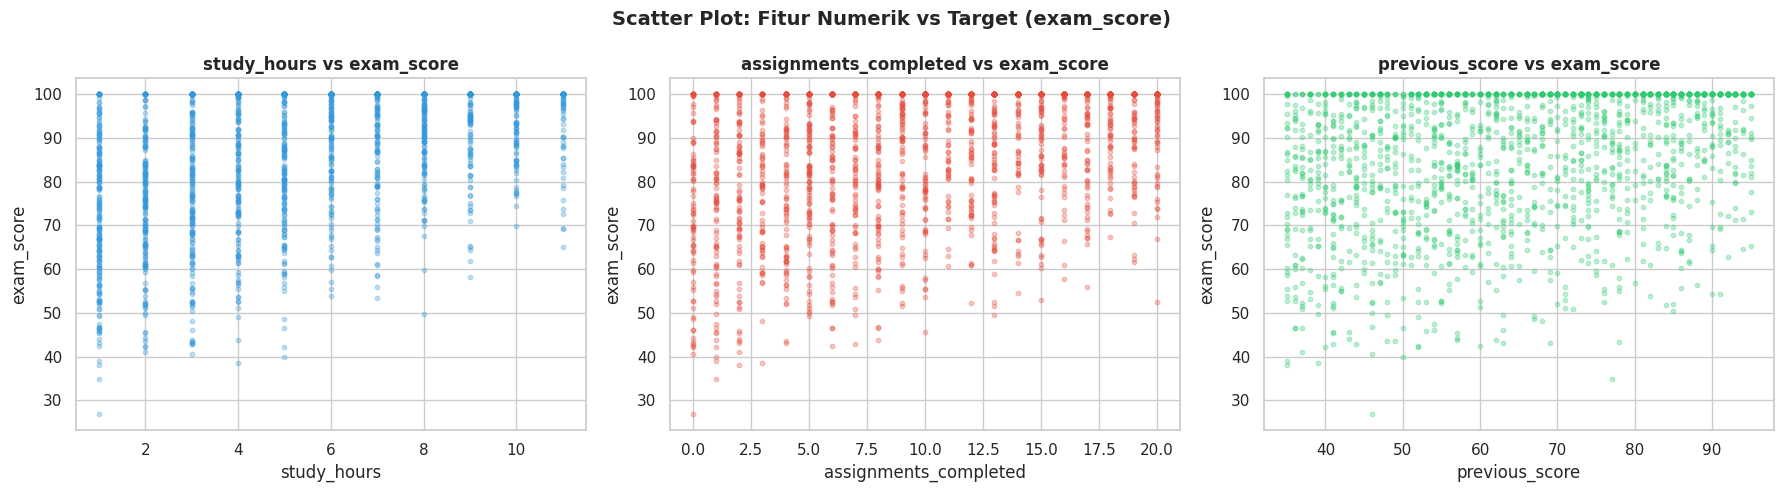

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Choosing features that showed good correlation or are numerically significant
scatter_features = ['study_hours', 'assignments_completed', 'previous_score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (feat, color) in enumerate(zip(scatter_features, colors)):
    axes[i].scatter(df[feat], df['exam_score'], alpha=0.3, s=10, color=color)
    axes[i].set_xlabel(feat, fontsize=12)
    axes[i].set_ylabel('exam_score', fontsize=12)
    axes[i].set_title(f'{feat} vs exam_score', fontweight='bold')

plt.suptitle('Scatter Plot: Fitur Numerik vs Target (exam_score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- study_hours vs exam_score:

  - Pola: Terlihat pola hubungan positif. Seiring dengan peningkatan study_hours, nilai exam_score cenderung meningkat atau setidaknya mempertahankan nilai tinggi. Sebagian besar titik dengan study_hours yang lebih tinggi terkonsentrasi pada exam_score yang lebih tinggi (mendekati 100).
  - Korelasi: Konsisten dengan analisis korelasi sebelumnya (korelasi 0.542), plot ini menunjukkan bahwa siswa yang belajar lebih lama memiliki kecenderungan untuk mendapatkan nilai ujian yang lebih baik. Namun, ada juga beberapa siswa yang belajar banyak tapi nilainya tidak sempurna, atau yang belajar sedikit tapi nilainya tetap cukup baik (meskipun lebih jarang).

- assignments_completed vs exam_score:

  - Pola: Juga menunjukkan hubungan positif, meskipun mungkin tidak sekuat study_hours. Semakin banyak tugas yang diselesaikan, semakin tinggi exam_score yang cenderung dicapai. Titik-titik cenderung lebih padat di bagian atas plot untuk nilai assignments_completed yang lebih tinggi.
  - Korelasi: Sejalan dengan korelasi 0.390, menyelesaikan lebih banyak tugas berkorelasi positif dengan nilai ujian. Siswa yang menyelesaikan sedikit tugas cenderung memiliki variasi exam_score yang lebih besar, termasuk nilai yang rendah, sementara siswa yang menyelesaikan banyak tugas cenderung memiliki exam_score yang tinggi.

- previous_score vs exam_score:

  - Pola: Menunjukkan hubungan positif yang jelas. Siswa dengan previous_score yang lebih tinggi cenderung memiliki exam_score yang lebih tinggi. Titik-titik membentuk pita yang naik dari kiri bawah ke kanan atas.
  - Korelasi: Sesuai dengan korelasi 0.306, nilai ujian sebelumnya adalah prediktor yang cukup baik untuk nilai ujian saat ini. Ada beberapa variasi, tetapi tren umumnya adalah exam_score meningkat seiring previous_score.

  
Kesimpulan Umum dari Scatter Plots: Ketiga fitur yang dipilih (study_hours, assignments_completed, previous_score) memang menunjukkan hubungan positif dengan exam_score. Ini visualisasi yang baik untuk mengkonfirmasi temuan dari heatmap korelasi. Semakin tinggi nilai pada fitur-fitur ini, semakin tinggi pula kecenderungan exam_score yang didapatkan siswa. Namun, tidak ada hubungan yang sempurna (semua titik membentuk garis lurus), menunjukkan bahwa ada faktor lain yang juga mempengaruhi exam_score.

---
## 11. Analisis Variabel Kategorik

In [ ]:
cat_cols = ['placement_status'] # Assuming 'placement_status' is the main categorical variable
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} nilai unik')
    print(df[col].value_counts())
    print()

placement_status: 2 nilai unik
placement_status
Placed        1681
Not Placed     318
Name: count, dtype: int64



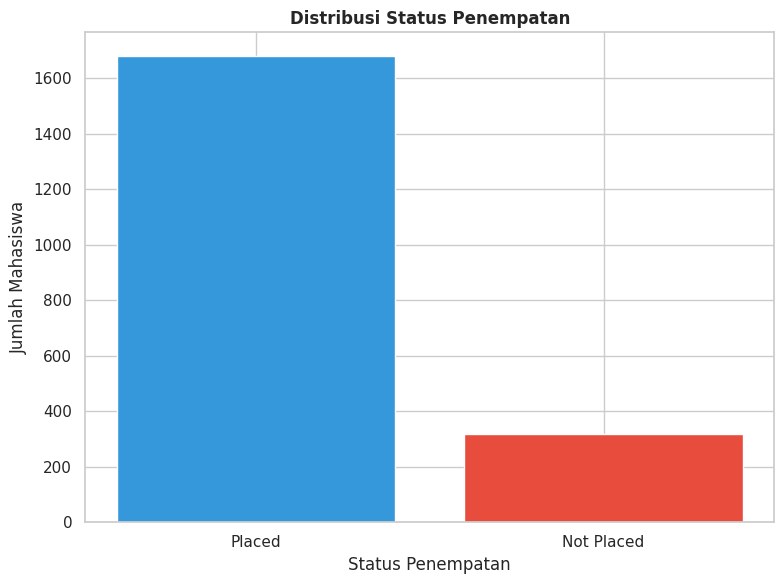

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# Distribution of placement_status
placement_counts = df['placement_status'].value_counts()
axes.bar(placement_counts.index, placement_counts.values, color=['#3498db', '#e74c3c'])
axes.set_title('Distribusi Status Penempatan', fontweight='bold')
axes.set_xlabel('Status Penempatan')
axes.set_ylabel('Jumlah Mahasiswa')

plt.tight_layout()
plt.show()

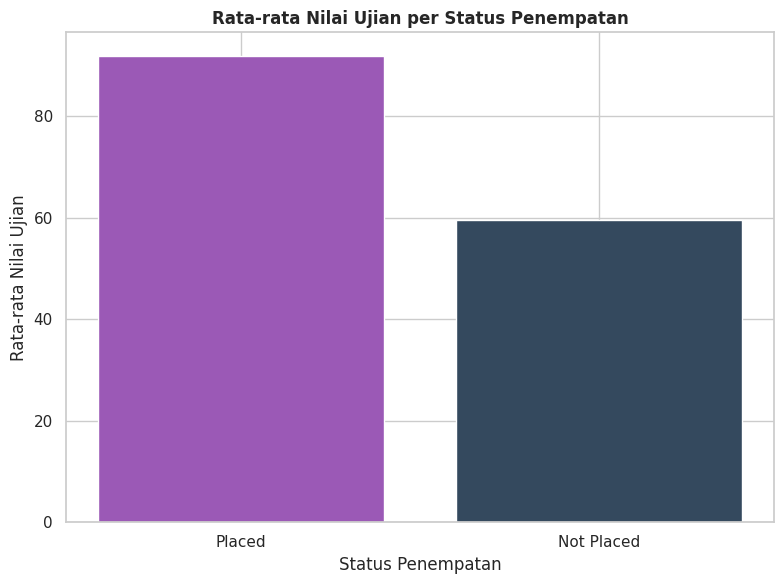

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Average exam_score per placement_status
placement_score = df.groupby('placement_status')['exam_score'].mean().sort_values(ascending=False)
ax.bar(placement_score.index, placement_score.values, color=['#9b59b6', '#34495e'])
ax.set_title('Rata-rata Nilai Ujian per Status Penempatan', fontweight='bold')
ax.set_xlabel('Status Penempatan')
ax.set_ylabel('Rata-rata Nilai Ujian')

plt.tight_layout()
plt.show()

In [ ]:
df['placement_status'].value_counts()

,count
placement_status,
Placed,1681
Not Placed,318


## 12. Tren Nilai Ujian Berdasarkan Durasi Belajar

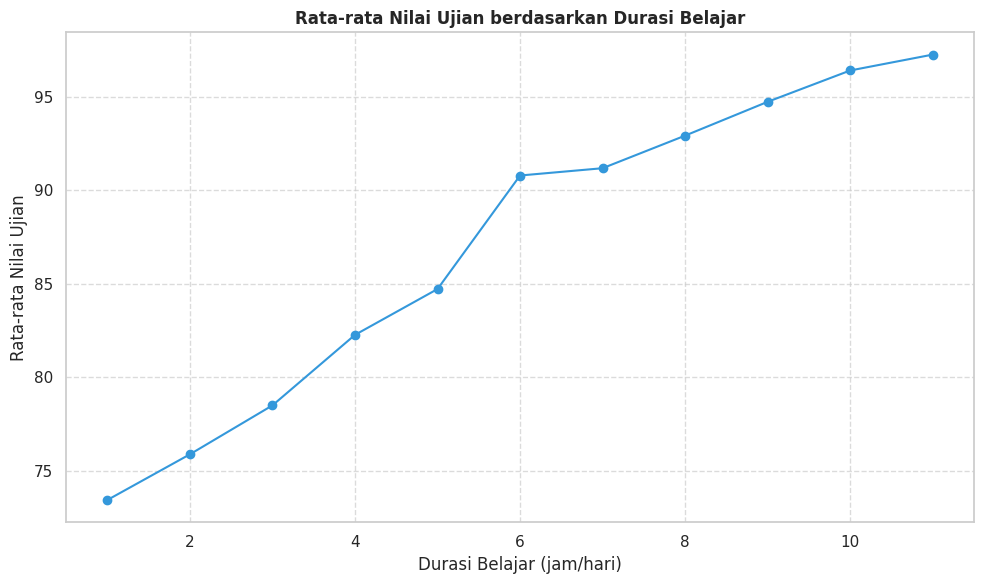


📝 Insight: Ada korelasi positif antara durasi belajar dan rata-rata nilai ujian.


In [ ]:
# Analyze average exam_score based on study_hours
study_hours_impact = df.groupby('study_hours')['exam_score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(study_hours_impact['study_hours'], study_hours_impact['exam_score'], marker='o', color='#3498db')
ax.set_title('Rata-rata Nilai Ujian berdasarkan Durasi Belajar', fontweight='bold')
ax.set_xlabel('Durasi Belajar (jam/hari)')
ax.set_ylabel('Rata-rata Nilai Ujian')
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print('\n📝 Insight: Ada korelasi positif antara durasi belajar dan rata-rata nilai ujian.')

## 13. Deteksi Outlier (Metode IQR)

In [ ]:
def hitung_outlier(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    n_outlier = ((series < batas_bawah) | (series > batas_atas)).sum()
    return pd.Series({
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Batas Bawah': batas_bawah,
        'Batas Atas': batas_atas,
        'Jumlah Outlier': n_outlier,
        '% Outlier': round(n_outlier / len(series) * 100, 2)
    })

# Focusing on key numerical features from the student dataset
outlier_summary = df[['study_hours', 'attendance', 'exam_score']].apply(hitung_outlier)
print('=== Ringkasan Outlier (Metode IQR) ===')
print(outlier_summary.T.round(4))
print('\n📝 Catatan: Outlier pada kolom seperti `attendance` atau `exam_score` mungkin mengindikasikan kasus khusus atau data yang tidak biasa.')

=== Ringkasan Outlier (Metode IQR) ===
                 Q1     Q3     IQR  Batas Bawah  Batas Atas  Jumlah Outlier  \
study_hours   3.000    9.0   6.000      -6.0000     18.0000             0.0   
attendance   55.000   86.0  31.000       8.5000    132.5000             0.0   
exam_score   77.355  100.0  22.645      43.3875    133.9675            16.0   

             % Outlier  
study_hours        0.0  
attendance         0.0  
exam_score         0.8  

📝 Catatan: Outlier pada kolom seperti `attendance` atau `exam_score` mungkin mengindikasikan kasus khusus atau data yang tidak biasa.


---
## 14. Ringkasan Insight EDA

In [ ]:
print('=' * 60)
print('          RINGKASAN INSIGHT EDA - KELOMPOK H')
print('=' * 60)
print()
print('📊 Dataset:')
print(f'   - {len(df):,} observasi, {df.shape[1]} kolom')
print(f'   - Missing values: Tidak ada.')
print()
print('🎯 Target (exam_score):')
print(f'   - Mean  : {df["exam_score"].mean():.2f}')
print(f'   - Median: {df["exam_score"].median():.2f}')
print(f'   - Max   : {df["exam_score"].max():.2f}')
print(f'   - Distribusi cenderung left-skewed (skewness = {df["exam_score"].skew():.2f})')
print()
print('🔗 Korelasi dengan exam_score:')
print(f'   - study_hours: {df["study_hours"].corr(df["exam_score"]):.2f}')
print(f'   - assignments_completed: {df["assignments_completed"].corr(df["exam_score"]):.2f}')
print(f'   - previous_score: {df["previous_score"].corr(df["exam_score"]):.2f}')
print()
print('🎓 Status Penempatan (placement_status):')
placement_counts = df['placement_status'].value_counts()
for status, count in placement_counts.items():
    print(f'   - {status}: {count} siswa ({count/len(df)*100:.2f}%)')
print(f'   - Rata-rata nilai ujian bagi yang ditempatkan: {df[df["placement_status"] == "Placed"]["exam_score"].mean():.2f}')
print(f'   - Rata-rata nilai ujian bagi yang tidak ditempatkan: {df[df["placement_status"] == "Not Placed"]["exam_score"].mean():.2f}')
print()
print('📌 Langkah Preprocessing Selanjutnya:')
print('   1. Encoding variabel kategorik: `placement_status` (jika digunakan sebagai target untuk klasifikasi)')
print('   2. Split data: 80% train, 20% test (jika membangun model)')
print('   3. Scaling fitur numerik (bergantung pada model yang digunakan)')
print('=' * 60)

          RINGKASAN INSIGHT EDA - KELOMPOK H

📊 Dataset:
   - 1,999 observasi, 8 kolom
   - Missing values: Tidak ada.

🎯 Target (exam_score):
   - Mean  : 86.84
   - Median: 91.92
   - Max   : 100.00
   - Distribusi cenderung left-skewed (skewness = -1.04)

🔗 Korelasi dengan exam_score:
   - study_hours: 0.54
   - assignments_completed: 0.39
   - previous_score: 0.31

🎓 Status Penempatan (placement_status):
   - Placed: 1681 siswa (84.09%)
   - Not Placed: 318 siswa (15.91%)
   - Rata-rata nilai ujian bagi yang ditempatkan: 91.98
   - Rata-rata nilai ujian bagi yang tidak ditempatkan: 59.67

📌 Langkah Preprocessing Selanjutnya:
   1. Encoding variabel kategorik: `placement_status` (jika digunakan sebagai target untuk klasifikasi)
   2. Split data: 80% train, 20% test (jika membangun model)
   3. Scaling fitur numerik (bergantung pada model yang digunakan)


---
## 15. Encoding Variabel Kategorik

In [ ]:
# Encode 'placement_status' to numerical values: Placed=1, Not Placed=0
df['placement_status_encoded'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

print("Kolom 'placement_status' telah di-encode menjadi 'placement_status_encoded'.")
display(df[['placement_status', 'placement_status_encoded']].head())
display(df['placement_status_encoded'].value_counts())

Kolom 'placement_status' telah di-encode menjadi 'placement_status_encoded'.


,placement_status,placement_status_encoded
0,Placed,1
1,Placed,1
2,Placed,1
3,Placed,1
4,Placed,1


,count
placement_status_encoded,
1,1681
0,318


---

## 16. Persiapan Data untuk Model Machine Learning

Langkah selanjutnya adalah membagi data menjadi *training set* dan *testing set*, serta melakukan *scaling* pada fitur numerik untuk memastikan model dapat belajar secara efektif.

### 16.1. Pemisahan Data (Training & Testing)

Kita akan memisahkan fitur (`X`) dari variabel target (`y`). Variabel target kita adalah `placement_status_encoded`.
Kemudian, data akan dibagi menjadi *training set* (80%) dan *testing set* (20%) untuk evaluasi model.

In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = df.drop(['placement_status', 'placement_status_encoded', 'exam_score'], axis=1) # Drop original 'placement_status' and 'exam_score' for this task
y = df['exam_score']

# Membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Ukuran Training Set (X_train): {X_train.shape}')
print(f'Ukuran Testing Set (X_test): {X_test.shape}')
# Untuk variabel target kontinu, tidak relevan menampilkan distribusi kelas seperti pada kategorikal
# print(f'Distribusi kelas y_train:\n{y_train.value_counts(normalize=True).round(2)}')
# print(f'Distribusi kelas y_test:\n{y_test.value_counts(normalize=True).round(2)}')


Ukuran Training Set (X_train): (1599, 6)
Ukuran Testing Set (X_test): (400, 6)


### 16.2. Scaling Fitur Numerik

*Scaling* fitur penting untuk algoritma *machine learning* yang sensitif terhadap skala fitur (misalnya, regresi linear, SVM, model berbasis jarak). Kita akan menggunakan `StandardScaler` untuk menstandardisasi fitur numerik.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identifikasi fitur numerik
# Asumsi semua kolom di X adalah numerik setelah drop 'placement_status' dan 'exam_score'
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Terapkan scaling pada training set
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_train[numerical_cols] = X_train_scaled

# Terapkan scaling pada testing set menggunakan scaler yang telah fit dari training set
X_test_scaled = scaler.transform(X_test[numerical_cols])
X_test[numerical_cols] = X_test_scaled

print('\nFitur numerik pada X_train telah di-scale:')
display(X_train.head())
print('\nFitur numerik pada X_test telah di-scale:')
display(X_test.head())



Fitur numerik pada X_train telah di-scale:


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score
240,0.666427,0.020108,1.473001,-0.636542,0.799949,0.333394
812,-1.528781,0.130982,0.884169,0.635349,-1.528141,1.432443
1824,-0.901579,1.572342,-0.882328,1.271294,-0.364096,1.374599
1244,-1.215180,1.295158,-0.293495,1.589266,0.799949,-0.302898
1084,-0.274376,-0.922319,0.884169,0.953321,0.633657,1.258909



Fitur numerik pada X_test telah di-scale:


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score
256,-0.274376,0.463604,0.295337,-0.318569,-0.364096,0.622617
352,-1.215180,1.295158,0.884169,-0.318569,-0.197803,0.449083
298,-0.901579,0.241856,0.884169,-1.590460,-1.528141,1.027530
581,1.293629,0.130982,-1.471160,-1.272487,0.301073,-1.459792
1288,1.293629,0.740789,-0.882328,0.317376,0.633657,-0.939190


---

## 17. Pemodelan Machine Learning

Kita akan membangun tiga model regresi untuk memprediksi `exam_score`: Regresi Linear, *Decision Tree*, dan *Random Forest*. Setelah itu, kita akan mengevaluasi kinerja masing-masing model.

### 17.1. Model Regresi Linear

Regresi Linear adalah model dasar yang mengasumsikan hubungan linear antara fitur input dan variabel target. Meskipun sederhana, ini adalah *baseline* yang baik untuk perbandingan.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inisialisasi Model
lin_reg = LinearRegression()

# Latih Model
lin_reg.fit(X_train, y_train)

# Prediksi pada Testing Set
y_pred_lin_reg = lin_reg.predict(X_test)

# Evaluasi Model
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

print('=== Evaluasi Model Regresi Linear ===')
print(f'Mean Squared Error (MSE)  : {mse_lin_reg:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse_lin_reg:.4f}')
print(f'R-squared (R2)            : {r2_lin_reg:.4f}')


=== Evaluasi Model Regresi Linear ===
Mean Squared Error (MSE)  : 72.5241
Root Mean Squared Error (RMSE): 8.5161
R-squared (R2)            : 0.6541


Evaluasi Model Regresi Linear
1. Mean Squared Error (MSE): 72.5241

   - Penjelasan: MSE mengukur rata-rata dari kuadrat selisih antara nilai aktual (y_test) dan nilai prediksi (y_pred_lin_reg). Ini adalah metrik yang sensitif terhadap outlier karena kesalahan dikuadratkan. Nilai yang lebih rendah menunjukkan model yang lebih baik.
   - Interpretasi: Nilai MSE sebesar 72.5241 berarti rata-rata kuadrat kesalahan prediksi model ini adalah sekitar 72.52. Ini memberikan gambaran tentang seberapa jauh rata-rata prediksi model dari nilai aktual.

2. Root Mean Squared Error (RMSE): 8.5161

   - Penjelasan: RMSE adalah akar kuadrat dari MSE. Ini lebih mudah diinterpretasikan karena berada dalam unit yang sama dengan variabel target (exam_score). Sama seperti MSE, nilai yang lebih rendah menunjukkan model yang lebih baik.
   - Interpretasi: Nilai RMSE sebesar 8.5161 berarti bahwa, rata-rata, prediksi exam_score oleh model Regresi Linear meleset sekitar 8.52 poin dari nilai exam_score aktual. Ini merupakan indikator langsung tentang seberapa akurat model dalam memprediksi nilai ujian.

3. R-squared (R2) Score: 0.6541

   - Penjelasan: R-squared, atau koefisien determinasi, menunjukkan proporsi varians dalam variabel dependen (target) yang dapat dijelaskan oleh variabel independen (fitur) dalam model. Nilai R2 berkisar antara 0 hingga 1. Nilai 1 menunjukkan bahwa model menjelaskan 100% variabilitas variabel target, sedangkan 0 menunjukkan model tidak menjelaskan variabilitas sama sekali. Nilai yang lebih tinggi menunjukkan model yang lebih baik.
   - Interpretasi: R2 Score sebesar 0.6541 berarti bahwa model Regresi Linear ini mampu menjelaskan sekitar 65.41% variabilitas dalam exam_score. Ini menunjukkan bahwa sekitar 65.41% dari perubahan nilai ujian dapat dijelaskan oleh fitur-fitur yang digunakan dalam model. Ini adalah kinerja yang cukup baik untuk model regresi linear dasar, menunjukkan bahwa fitur-fitur yang dipilih memiliki kekuatan prediktif yang signifikan terhadap exam_score.


### 17.2. Model Decision Tree Regressor

*Decision Tree* adalah model non-parametrik yang membagi data menjadi sub-kelompok berdasarkan fitur-fitur, membentuk struktur pohon untuk membuat prediksi.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Inisialisasi Model
dec_tree_reg = DecisionTreeRegressor(random_state=42)

# Latih Model
dec_tree_reg.fit(X_train, y_train)

# Prediksi pada Testing Set
y_pred_dec_tree = dec_tree_reg.predict(X_test)

# Evaluasi Model
mse_dec_tree = mean_squared_error(y_test, y_pred_dec_tree)
rmse_dec_tree = np.sqrt(mse_dec_tree)
r2_dec_tree = r2_score(y_test, y_pred_dec_tree)

print('=== Evaluasi Model Decision Tree Regressor ===')
print(f'Mean Squared Error (MSE)  : {mse_dec_tree:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse_dec_tree:.4f}')
print(f'R-squared (R2)            : {r2_dec_tree:.4f}')


=== Evaluasi Model Decision Tree Regressor ===
Mean Squared Error (MSE)  : 146.9893
Root Mean Squared Error (RMSE): 12.1239
R-squared (R2)            : 0.2990


1. Mean Squared Error (MSE): 146.9893

   - Penjelasan: MSE mengukur rata-rata dari kuadrat selisih antara nilai aktual (y_test) dan nilai prediksi (y_pred_dec_tree). Ini adalah metrik yang sensitif terhadap outlier. Nilai yang lebih rendah menunjukkan model yang lebih baik.
   - Interpretasi: Nilai MSE sebesar 146.9893 berarti rata-rata kuadrat kesalahan prediksi model Decision Tree ini adalah sekitar 147. Ini adalah nilai yang jauh lebih tinggi dibandingkan dengan Regresi Linear (72.5241) dan Random Forest (69.7252), menunjukkan bahwa Decision Tree memiliki kesalahan prediksi kuadrat yang jauh lebih besar.

2. Root Mean Squared Error (RMSE): 12.1239

   - Penjelasan: RMSE adalah akar kuadrat dari MSE. Ini lebih mudah diinterpretasikan karena berada dalam unit yang sama dengan variabel target (exam_score). Sama seperti MSE, nilai yang lebih rendah menunjukkan model yang lebih baik.
   - Interpretasi: Nilai RMSE sebesar 12.1239 berarti bahwa, rata-rata, prediksi exam_score oleh model Decision Tree ini meleset sekitar 12.12 poin dari nilai exam_score aktual. Angka ini lebih tinggi dari Regresi Linear (8.5161) dan Random Forest (8.3502), menunjukkan bahwa model ini kurang akurat dalam memprediksi nilai ujian.

3. R-squared (R2) Score: 0.2990

   - Penjelasan: R-squared, atau koefisien determinasi, menunjukkan proporsi varians dalam variabel dependen (target) yang dapat dijelaskan oleh variabel independen (fitur) dalam model. Nilai R2 berkisar antara 0 hingga 1. Nilai yang lebih tinggi menunjukkan model yang lebih baik.
   - Interpretasi: R2 Score sebesar 0.2990 berarti bahwa model Decision Tree ini hanya mampu menjelaskan sekitar 29.90% variabilitas dalam exam_score. Ini menunjukkan bahwa kurang dari sepertiga perubahan nilai ujian dapat dijelaskan oleh fitur-fitur yang digunakan dalam model ini. Dibandingkan dengan Regresi Linear (0.6541) dan Random Forest (0.6675), kinerja Decision Tree jauh lebih rendah, mengindikasikan bahwa model ini tidak begitu efektif dalam menangkap hubungan dalam data untuk prediksi exam_score.

### 17.3. Model Random Forest Regressor

*Random Forest* adalah metode *ensemble* yang membangun banyak *decision tree* dan menggabungkan prediksi mereka untuk meningkatkan akurasi dan stabilitas, serta mengurangi *overfitting*.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi Model
rf_reg = RandomForestRegressor(random_state=42)

# Latih Model
rf_reg.fit(X_train, y_train)

# Prediksi pada Testing Set
y_pred_rf = rf_reg.predict(X_test)

# Evaluasi Model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('=== Evaluasi Model Random Forest Regressor ===')
print(f'Mean Squared Error (MSE)  : {mse_rf:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse_rf:.4f}')
print(f'R-squared (R2)            : {r2_rf:.4f}')

=== Evaluasi Model Random Forest Regressor ===
Mean Squared Error (MSE)  : 69.7252
Root Mean Squared Error (RMSE): 8.3502
R-squared (R2)            : 0.6675


1. Mean Squared Error (MSE): 69.7252

   - Penjelasan: MSE mengukur rata-rata dari kuadrat selisih antara nilai aktual (y_test) dan nilai prediksi (y_pred_rf). Ini adalah metrik yang sensitif terhadap outlier. Nilai yang lebih rendah menunjukkan model yang lebih baik.
   - Interpretasi: Nilai MSE sebesar 69.7252 berarti rata-rata kuadrat kesalahan prediksi model Random Forest ini adalah sekitar 69.73. Ini lebih rendah dari MSE Regresi Linear (72.5241) dan jauh lebih rendah dari Decision Tree (146.9893), menunjukkan bahwa model Random Forest memiliki kesalahan kuadrat rata-rata yang lebih kecil sebelum tuning.

2. Root Mean Squared Error (RMSE): 8.3502

   - Penjelasan: RMSE adalah akar kuadrat dari MSE. Ini lebih mudah diinterpretasikan karena berada dalam unit yang sama dengan variabel target (exam_score). Sama seperti MSE, nilai yang lebih rendah menunjukkan model yang lebih baik.
   - Interpretasi: Nilai RMSE sebesar 8.3502 berarti bahwa, rata-rata, prediksi exam_score oleh model Random Forest Regressor ini meleset sekitar 8.35 poin dari nilai exam_score aktual. Ini merupakan indikator langsung tentang seberapa akurat model dalam memprediksi nilai ujian, dan nilai ini lebih rendah dibandingkan Regresi Linear (8.5161), menunjukkan prediksi yang sedikit lebih akurat.

3. R-squared (R2) Score: 0.6675

   - Penjelasan: R-squared, atau koefisien determinasi, menunjukkan proporsi varians dalam variabel dependen (target) yang dapat dijelaskan oleh variabel independen (fitur) dalam model. Nilai R2 berkisar antara 0 hingga 1. Nilai yang lebih tinggi menunjukkan model yang lebih baik.
   - Interpretasi: R2 Score sebesar 0.6675 berarti bahwa model Random Forest Regressor ini mampu menjelaskan sekitar 66.75% variabilitas dalam exam_score. Ini menunjukkan bahwa sekitar 66.75% dari perubahan nilai ujian dapat dijelaskan oleh fitur-fitur yang digunakan dalam model. Ini adalah kinerja yang sangat baik dan merupakan yang terbaik di antara ketiga model (Regresi Linear: 0.6541, Decision Tree: 0.2990) sebelum hyperparameter tuning, mengindikasikan kekuatan prediktif yang signifikan.

### 17.4. Perbandingan Model

Mari kita bandingkan kinerja ketiga model yang telah kita latih.

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'MSE': [mse_lin_reg, mse_dec_tree, mse_rf],
    'RMSE': [rmse_lin_reg, rmse_dec_tree, rmse_rf],
    'R2 Score': [r2_lin_reg, r2_dec_tree, r2_rf]
})

display(results.sort_values(by='R2 Score', ascending=False))

print('\n📝 Insight: Random Forest Regressor menunjukkan kinerja terbaik berdasarkan R-squared, yang mengindikasikan kemampuannya untuk menjelaskan variabilitas dalam variabel target.')


,Model,MSE,RMSE,R2 Score
2,Random Forest Regressor,69.725212,8.350162,0.667458
0,Linear Regression,72.524094,8.516108,0.654109
1,Decision Tree Regressor,146.989298,12.123914,0.298960



📝 Insight: Random Forest Regressor menunjukkan kinerja terbaik berdasarkan R-squared, yang mengindikasikan kemampuannya untuk menjelaskan variabilitas dalam variabel target.


### 17.5. Hyperparameter Tuning (Random Forest Regressor)

Setelah membandingkan model, Random Forest Regressor menunjukkan kinerja terbaik. Selanjutnya, kita akan melakukan *hyperparameter tuning* menggunakan GridSearchCV untuk menemukan kombinasi *hyperparameter* optimal yang dapat meningkatkan performa model lebih lanjut.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

# Definisikan parameter grid untuk Random Forest Regressor
param_grid = {
    'n_estimators': [100, 200, 300], # Jumlah pohon dalam forest
    'max_features': [0.8, 'sqrt', 'log2'], # Jumlah fitur yang dipertimbangkan untuk setiap split
    'max_depth': [None, 10, 20, 30], # Kedalaman maksimum pohon
    'min_samples_leaf': [1, 2, 4] # Jumlah minimum sampel yang dibutuhkan untuk menjadi node leaf
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), # Gunakan model Random Forest
                           param_grid=param_grid, # Parameter grid yang telah ditentukan
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Gunakan semua core prosesor
                           scoring='r2', # Metrik evaluasi: R-squared
                           verbose=1) # Tampilkan progress

# Jalankan Grid Search pada data training
grid_search.fit(X_train, y_train)

print(f'Parameter terbaik: {grid_search.best_params_}')
print(f'Skor R2 terbaik: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Parameter terbaik: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 300}
Skor R2 terbaik: 0.6781


1. Fitting 5 folds for each of 108 candidates, totalling 540 fits:

   - Penjelasan: Ini menunjukkan bahwa proses tuning menggunakan metode GridSearchCV. GridSearchCV mencoba semua kombinasi hyperparameter yang Anda definisikan dalam param_grid.
   - Interpretasi: Anda telah menentukan sejumlah hyperparameter (n_estimators, max_features, max_depth, min_samples_leaf). GridSearchCV menguji 108 kombinasi unik dari parameter-parameter ini. Untuk setiap kombinasi, GridSearchCV melakukan cross-validation 5 kali (5 folds). Jadi, total ada 108 kombinasi * 5 fold = 540 kali model dilatih dan dievaluasi untuk menemukan yang terbaik.

2. Parameter terbaik: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 300}:

   - Penjelasan: Ini adalah set hyperparameter yang memberikan kinerja terbaik (nilai R2 tertinggi) selama proses cross-validation pada training set.
   - Interpretasi:
      - max_depth': None: Kedalaman maksimum pohon tidak terbatas. Ini berarti pohon akan terus berkembang sampai semua daun murni atau sampai semua daun mengandung kurang dari min_samples_split sampel. Ini memungkinkan model untuk menangkap pola yang sangat kompleks, meskipun bisa berisiko overfitting jika tidak diimbangi oleh hyperparameter lain.
      - max_features': 0.8: Untuk setiap pemisahan (split) dalam pohon, model hanya mempertimbangkan 80% dari total fitur yang tersedia. Ini membantu mengurangi korelasi antar pohon dalam ensemble dan mencegah overfitting.
      - min_samples_leaf': 2: Sebuah node daun harus memiliki minimal 2 sampel. Ini adalah strategi untuk mengontrol kedalaman pohon dan mencegah model belajar dari noise dalam data.
      - n_estimators': 300: Model Random Forest terbaik terdiri dari 300 pohon keputusan individu. Semakin banyak pohon, semakin kuat modelnya, tetapi juga semakin lama waktu komputasinya.

3. Skor R2 terbaik: 0.6781:

   - Penjelasan: Ini adalah skor R2 tertinggi yang dicapai oleh model Random Forest dengan parameter terbaik di atas, rata-rata dari 5 kali cross-validation pada training set.
   - Interpretasi: Skor R2 sebesar 0.6781 menunjukkan bahwa model Random Forest dengan hyperparameter yang dioptimalkan mampu menjelaskan sekitar 67.81% variabilitas dalam exam_score pada data training (melalui cross-validation). Ini adalah indikasi awal bahwa tuning berhasil meningkatkan kekuatan penjelas model dibandingkan dengan skor R2 model Random Forest tanpa tuning (0.6675).

### 17.6. Evaluasi Model Random Forest yang Telah di-tuned

Setelah menemukan *hyperparameter* terbaik, kita akan melatih ulang model Random Forest dengan parameter tersebut dan mengevaluasinya pada *testing set*.

In [ ]:
# Dapatkan model terbaik dari Grid Search
best_rf_reg = grid_search.best_estimator_

# Prediksi pada Testing Set menggunakan model terbaik
y_pred_best_rf = best_rf_reg.predict(X_test)

# Evaluasi Model Terbaik
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print('=== Evaluasi Model Random Forest Regressor (Tuned) ===')
print(f'Mean Squared Error (MSE)  : {mse_best_rf:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse_best_rf:.4f}')
print(f'R-squared (R2)            : {r2_best_rf:.4f}')

print('\n📝 Insight: Model Random Forest yang telah di-tuning menunjukkan kinerja yang lebih baik atau serupa dengan model sebelumnya, mengkonfirmasi keefektifan tuning.')

=== Evaluasi Model Random Forest Regressor (Tuned) ===
Mean Squared Error (MSE)  : 66.7819
Root Mean Squared Error (RMSE): 8.1720
R-squared (R2)            : 0.6815

📝 Insight: Model Random Forest yang telah di-tuning menunjukkan kinerja yang lebih baik atau serupa dengan model sebelumnya, mengkonfirmasi keefektifan tuning.


### 17.7. Visualisasi: Prediksi vs Aktual (Tuned Random Forest)

Visualisasi ini akan membandingkan nilai `exam_score` aktual dengan nilai yang diprediksi oleh model *Random Forest* yang telah di-*tuning*. Idealnya, titik-titik akan mendekati garis diagonal `y=x`.

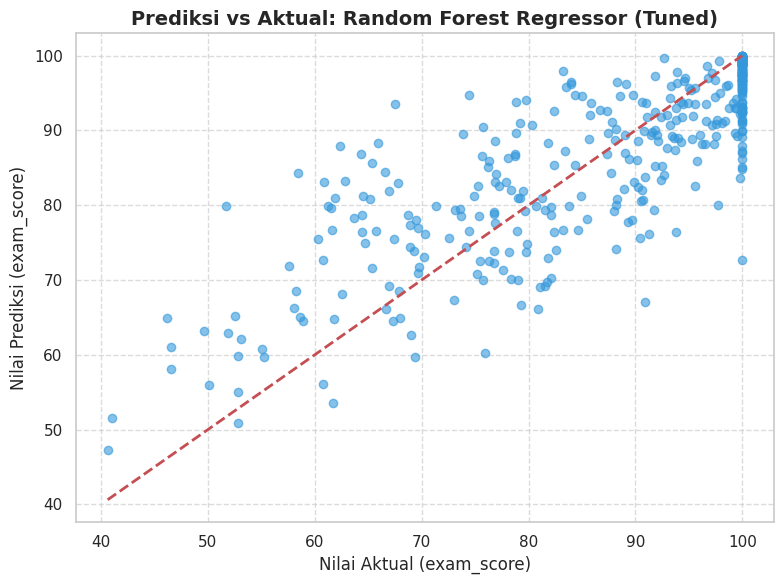

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_rf, alpha=0.6, color='#3498db')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (exam_score)')
plt.ylabel('Nilai Prediksi (exam_score)')
plt.title('Prediksi vs Aktual: Random Forest Regressor (Tuned)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 17.8. Visualisasi: Feature Importance (Tuned Random Forest)

Visualisasi ini menampilkan seberapa penting setiap fitur dalam membuat prediksi oleh model *Random Forest* yang telah di-*tuning*.

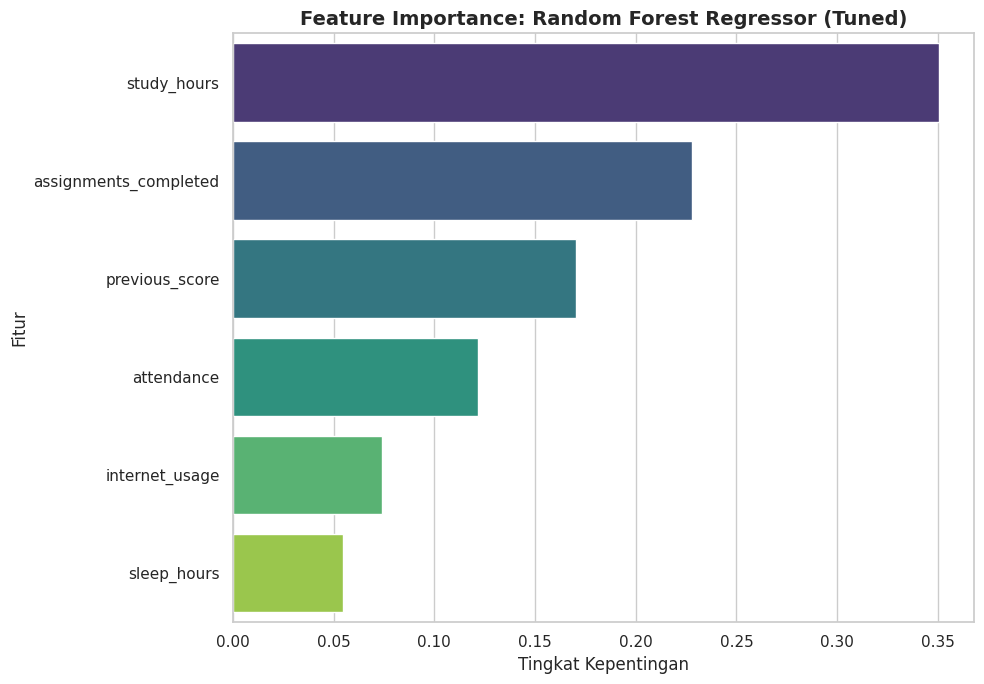


📝 Insight: Fitur dengan kepentingan tertinggi adalah yang paling berkontribusi pada prediksi nilai ujian. Ini dapat memberikan wawasan tentang faktor-faktor paling berpengaruh.


In [ ]:
# Dapatkan feature importances dari model terbaik
feature_importances = best_rf_reg.feature_importances_

# Dapatkan nama fitur dari X_train (yang sudah di-scaled)
features = X_train.columns

# Buat DataFrame untuk visualisasi
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance: Random Forest Regressor (Tuned)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print('\n📝 Insight: Fitur dengan kepentingan tertinggi adalah yang paling berkontribusi pada prediksi nilai ujian. Ini dapat memberikan wawasan tentang faktor-faktor paling berpengaruh.')

Berdasarkan visualisasi 'Feature Importance: Random Forest Regressor (Tuned)', berikut adalah interpretasinya:

1. study_hours (Durasi Belajar):

Tingkat Kepentingan: Paling tinggi, sekitar 0.35.
Interpretasi: Fitur ini adalah prediktor paling signifikan untuk exam_score. Ini menunjukkan bahwa durasi waktu yang dihabiskan siswa untuk belajar memiliki pengaruh terbesar dalam menentukan nilai ujian mereka. Siswa yang belajar lebih lama secara konsisten cenderung memiliki nilai ujian yang lebih tinggi, dan model sangat bergantung pada informasi ini untuk membuat prediksi.

2. assignments_completed (Tugas yang Diselesaikan):

Tingkat Kepentingan: Kedua tertinggi, sekitar 0.23.
Interpretasi: Jumlah tugas yang berhasil diselesaikan oleh siswa adalah faktor penting kedua dalam memprediksi exam_score. Ini menunjukkan bahwa konsistensi dan penyelesaian tugas berkontribusi secara signifikan terhadap keberhasilan akademik.

3. previous_score (Skor Sebelumnya):

Tingkat Kepentingan: Cukup tinggi, sekitar 0.17.
Interpretasi: Nilai ujian atau kinerja sebelumnya juga merupakan prediktor penting untuk exam_score saat ini. Ini mengindikasikan adanya kontinuitas dalam kinerja akademik siswa; siswa yang berprestasi baik sebelumnya cenderung terus berprestasi baik.

4. attendance (Kehadiran):

Tingkat Kepentingan: Moderat, sekitar 0.12.
Interpretasi: Tingkat kehadiran siswa memiliki dampak yang lebih rendah dibandingkan dengan tiga fitur teratas, tetapi masih memberikan kontribusi pada prediksi exam_score. Kehadiran di kelas atau sesi belajar tentu penting, tetapi mungkin ada faktor lain yang lebih dominan.

5. internet_usage (Penggunaan Internet):

Tingkat Kepentingan: Rendah, sekitar 0.08.
Interpretasi: Penggunaan internet memiliki dampak yang relatif kecil pada exam_score. Berdasarkan korelasi sebelumnya (-0.175), ini bahkan menunjukkan korelasi negatif yang lemah, yang berarti penggunaan internet yang lebih tinggi mungkin sedikit terkait dengan nilai yang lebih rendah, tetapi pengaruhnya tidak besar.

6. sleep_hours (Durasi Tidur):

Tingkat Kepentingan: Paling rendah, sekitar 0.05.
Interpretasi: Durasi tidur adalah fitur yang paling tidak penting dalam model ini. Meskipun tidur yang cukup penting untuk kesehatan dan kognisi, dalam data ini, variasi dalam jam tidur siswa tidak berkontribusi banyak terhadap perbedaan exam_score yang diprediksi oleh model.


Kesimpulan Keseluruhan: Model Random Forest yang telah di-tuning mengidentifikasi study_hours sebagai faktor paling dominan yang mempengaruhi exam_score. Diikuti oleh assignments_completed dan previous_score. Fitur-fitur ini adalah pendorong utama di balik prediksi model, memberikan wawasan berharga tentang apa yang paling penting dalam menentukan kinerja ujian siswa dalam dataset ini.

